# Import  Libs

In [173]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from utils import take_all_bending_setups

# Read pkl file

In [174]:
with open('../../data/experiments_process_and_results.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)

# See all available bending setup

In [175]:
all_bending_setups = take_all_bending_setups(loaded_dict)
experiment_number = 60
experiment_as_dictinary = loaded_dict.get(f'Exp_{experiment_number}')
for idx, key in enumerate(list(experiment_as_dictinary.keys())):
    print(f"{idx+1}-{key}")

1-geometry_data_key_characteristics_arc
2-geometry_data_key_characteristics_linear_1
3-geometry_data_key_characteristics_linear_2
4-geometry_data_stl_suitable_arc
5-geometry_data_stl_suitable_linear_1
6-geometry_data_stl_suitable_linear_2
7-process_parameters_loads_machine
8-process_parameters_loads_sensor
9-process_parameters_movements
10-bending_setups


In [176]:
experiment_as_dictinary['geometry_data_key_characteristics_arc'].head()

,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm],Tube_Section
0,0.0,22.220350,21.417203,0.036454,-0.614355,ARC
1,1.0,22.217831,21.387284,0.037698,-0.644275,ARC
2,2.0,22.215739,21.367266,0.038512,-0.664292,ARC
3,3.0,22.212448,21.355433,0.038899,-0.676125,ARC
4,4.0,22.207234,21.350766,0.038875,-0.680793,ARC


In [177]:
experiment_as_dictinary['geometry_data_stl_suitable_arc']['Tube_Section'].unique()

array(['ARC_1', 'ARC_0', 'ARC_10', 'ARC_11', 'ARC_12', 'ARC_13', 'ARC_14',
       'ARC_15', 'ARC_16', 'ARC_17', 'ARC_18', 'ARC_19', 'ARC_2',
       'ARC_20', 'ARC_21', 'ARC_22', 'ARC_23', 'ARC_24', 'ARC_25',
       'ARC_26', 'ARC_27', 'ARC_28', 'ARC_29', 'ARC_3', 'ARC_30',
       'ARC_31', 'ARC_32', 'ARC_33', 'ARC_34', 'ARC_35', 'ARC_36',
       'ARC_37', 'ARC_38', 'ARC_39', 'ARC_4', 'ARC_40', 'ARC_41',
       'ARC_42', 'ARC_43', 'ARC_44', 'ARC_45', 'ARC_5', 'ARC_6', 'ARC_7',
       'ARC_8', 'ARC_9'], dtype=object)

# Combine all process parameters

In [178]:
df_machine = experiment_as_dictinary['process_parameters_movements']
df_sensor = experiment_as_dictinary['process_parameters_loads_sensor']
df_movement = experiment_as_dictinary['process_parameters_loads_machine']

# Convert the types of the data to number and also set index

In [179]:
# Ensure 'Time_[s]' is the index for resampling
df_machine['Time_[s]'] = df_machine['Time_[s]'].astype(float)
df_machine.set_index('Time_[s]', inplace=True)
df_machine = df_machine.apply(pd.to_numeric, errors='coerce')
df_sensor['Time_[s]'] = df_sensor['Time_[s]'].astype(float)
df_sensor.set_index('Time_[s]', inplace=True)
df_sensor = df_sensor.apply(pd.to_numeric, errors='coerce')
df_movement['Time_[s]'] = df_movement['Time_[s]'].astype(float)
df_movement.set_index('Time_[s]', inplace=True)
df_movement = df_movement.apply(pd.to_numeric, errors='coerce')

# Resample the times in the datasets that has not good resolution

In [180]:
# Determine the common time range
start_time = max(df.index.min() for df in [df_machine, df_sensor, df_movement])
end_time = min(df.index.max() for df in [df_machine, df_sensor, df_movement])
# Create a common time index with desired frequency (0.01s)
time_index = pd.Index(np.arange(start_time, end_time + 0.01, 0.01), name='Time_[s]')  # use np.arange

In [181]:
# Reindex and interpolate missing values
df_machine_resampled = df_machine.reindex(time_index).interpolate(method='linear')
df_sensor_resampled = df_sensor.reindex(time_index).interpolate(method='linear')
df_movement_resampled = df_movement.reindex(time_index).interpolate(method='linear')

# Concatenate all datasets along columns
df_process_parameters = pd.concat([df_machine_resampled, df_sensor_resampled, df_movement_resampled], axis=1)

# Reset index if you want Time_[s] as a column again
df_process_parameters.reset_index(inplace=True)
df_process_parameters.index = df_process_parameters['Time_[s]']
df_process_parameters.drop(columns=['Time_[s]'], inplace = True)

In [182]:
df_process_parameters.head()   # 8562

,BEND-DIE_LATERAL_Movement_[mm],BEND-DIE_ROTATING_Angle_[°],BEND-DIE_VERTICAL_Movement_[mm],CLAMP-DIE_LATERAL_Movement_[mm],COLLET_AXIAL_Movement_[mm],COLLET_ROTATING_Movement_[mm],MANDREL_AXIAL_Movement_[mm],PRESSURE-DIE_AXIAL_Movement_[mm],PRESSURE-DIE_LATERAL_Movement_[mm],PRESSURE-DIE_LEFT_AXIAL_Movement_[mm],...,MACHINE_BEND-DIE_LATERAL_Max_Torque_[%],MACHINE_BEND-DIE_ROTATING_Max_Torque_[%],MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%],MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%],MACHINE_COLLET_AXIAL_Max_Torque_[%],MACHINE_COLLET_ROTATING_Max_Torque_[%],MACHINE_MANDREL_AXIAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_AXIAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque_[%]
Time_[s],,,,,,,,,,,,,,,,,,,,,
0.00,-33.0,90.0,19.75,150.0,-289.999908,209.880402,-2907.600098,-4.8,-20.0,-7.5,...,0.474934,0.429286,-11.777778,1.375,-1.009333,2.5,0.526316,0.0,11.868002,0.3
0.01,-33.0,90.0,19.75,150.0,-289.999927,209.880402,-2907.600098,-4.8,-20.0,-7.5,...,0.474934,0.429572,-11.777778,1.375,-1.009200,2.5,0.526316,0.0,11.849802,0.3
0.02,-33.0,90.0,19.75,150.0,-289.999945,209.880402,-2907.600098,-4.8,-20.0,-7.5,...,0.474934,0.429857,-11.777778,1.375,-1.009066,2.5,0.526316,0.0,11.831602,0.3
0.03,-33.0,90.0,19.75,150.0,-289.999963,209.880402,-2907.600098,-4.8,-20.0,-7.5,...,0.474934,0.430143,-11.777778,1.375,-1.008933,2.5,0.526316,0.0,11.813402,0.3
0.04,-33.0,90.0,19.75,150.0,-289.999982,209.880402,-2907.600098,-4.8,-20.0,-7.5,...,0.474934,0.430429,-11.777778,1.375,-1.008800,2.5,0.526316,0.0,11.795202,0.3


# Normalize and Plot

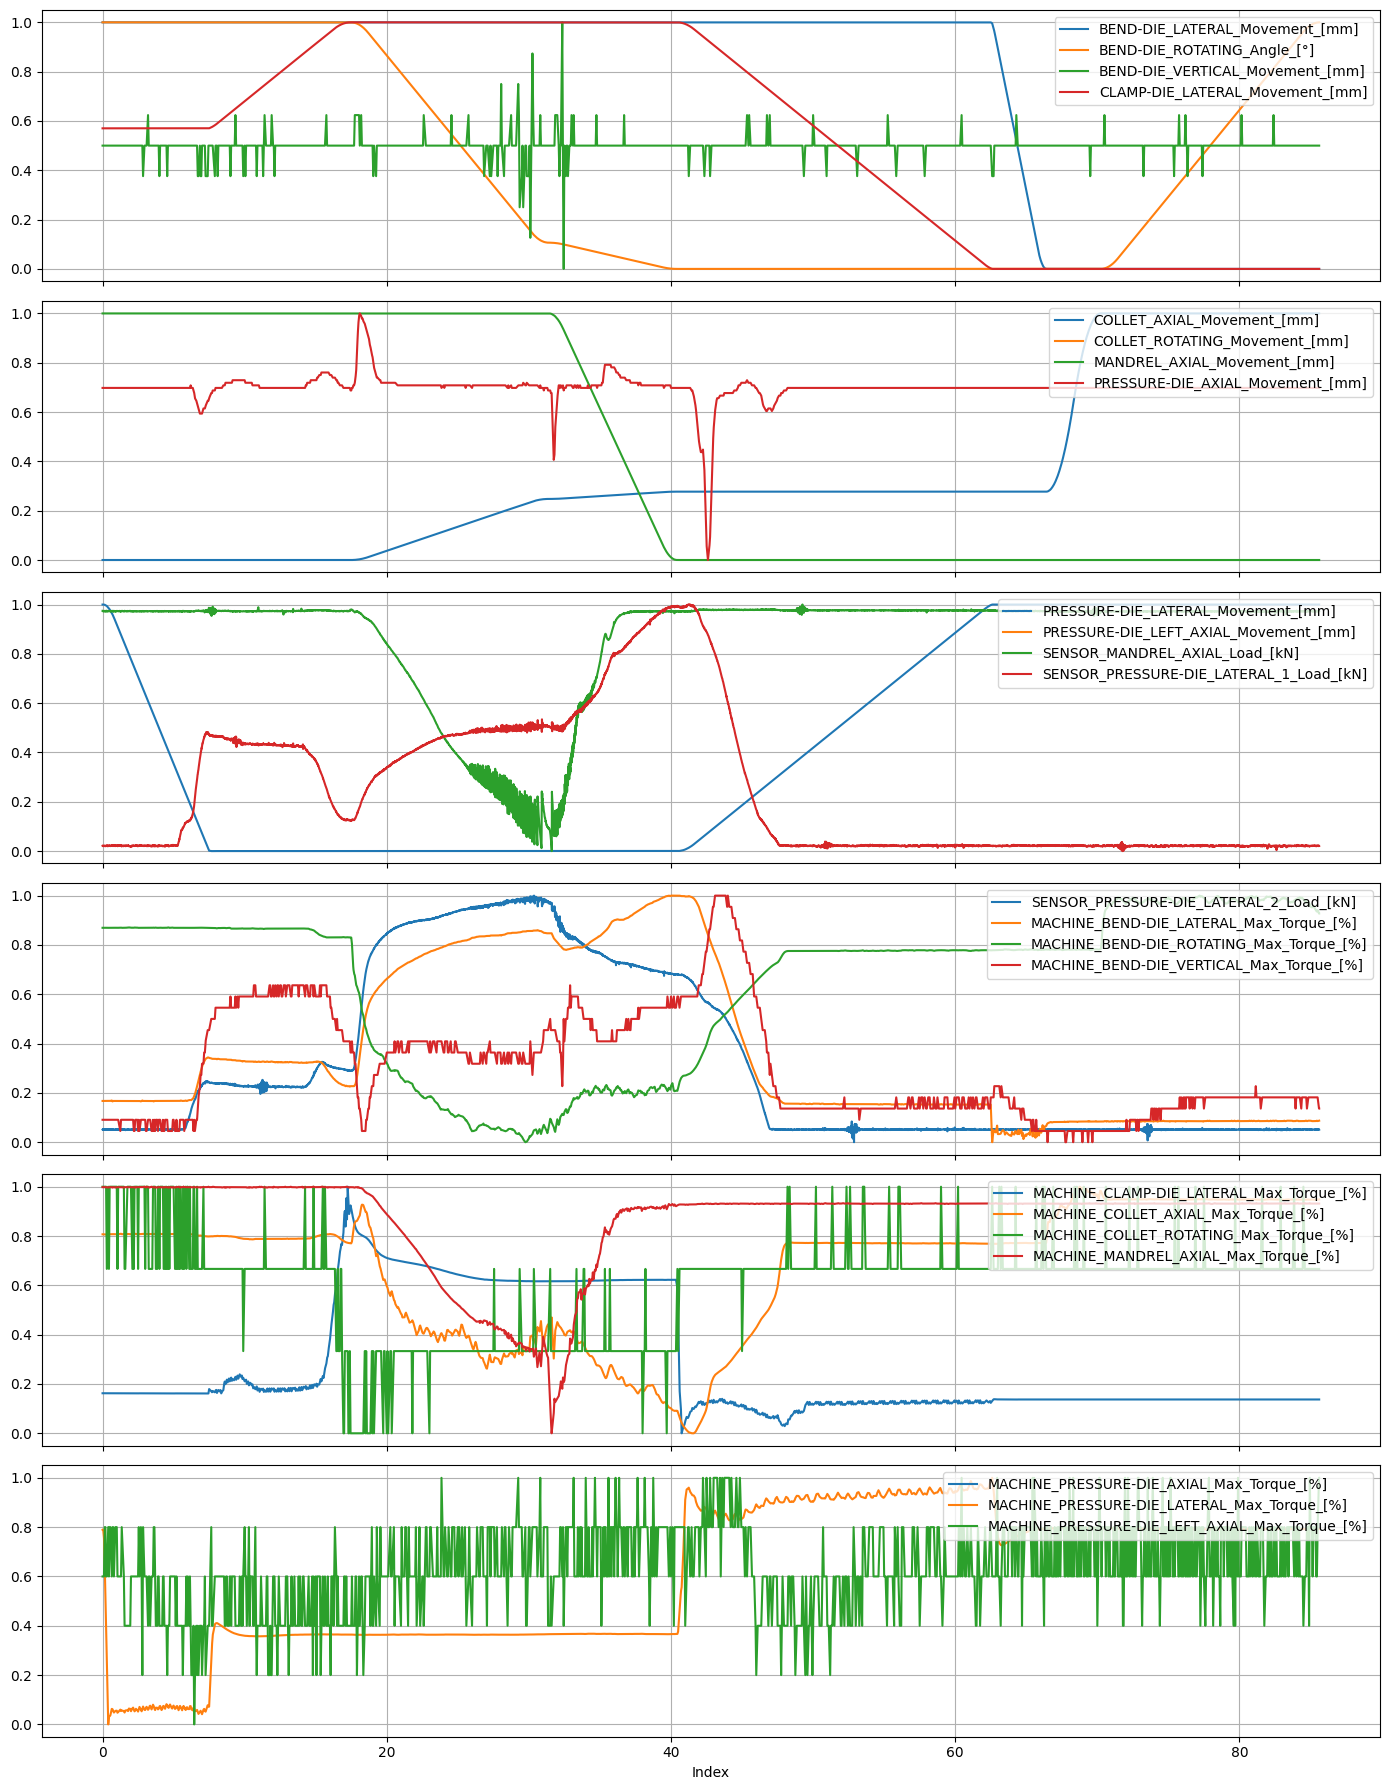

In [183]:
# Normalize the whole dataframe
df_process_parameters_norm = (df_process_parameters - df_process_parameters.min()) / (df_process_parameters.max() - df_process_parameters.min())

# Number of columns per subplot
cols_per_subplot = 4
num_cols = len(df_process_parameters_norm.columns)
num_subplots = int(np.ceil(num_cols / cols_per_subplot))

# Create figure
fig, axes = plt.subplots(nrows=num_subplots, ncols=1, figsize=(14, 3*num_subplots), sharex=True)

# Ensure axes is iterable
if num_subplots == 1:
    axes = [axes]

# Plot columns in groups of 4
for i in range(num_subplots):
    start_col = i * cols_per_subplot
    end_col = start_col + cols_per_subplot
    for j, col in enumerate(df_process_parameters_norm.columns[start_col:end_col]):
        axes[i].plot(df_process_parameters_norm.index, df_process_parameters_norm[col], label=col, color=f"C{j}")
    axes[i].legend(loc='upper right')
    axes[i].grid(True)

# Common X-label
axes[-1].set_xlabel("Index")

plt.tight_layout()
plt.show()


In [184]:
df_process_parameters.var().sort_values()

PRESSURE-DIE_LEFT_AXIAL_Movement_[mm]             0.000000e+00
MACHINE_PRESSURE-DIE_AXIAL_Max_Torque_[%]         0.000000e+00
COLLET_ROTATING_Movement_[mm]                     8.078879e-28
BEND-DIE_VERTICAL_Movement_[mm]                   8.721174e-10
PRESSURE-DIE_AXIAL_Movement_[mm]                  3.544098e-07
MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque_[%]    3.739977e-04
MACHINE_COLLET_ROTATING_Max_Torque_[%]            5.295556e-03
MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%]          3.238837e-02
SENSOR_PRESSURE-DIE_LATERAL_1_Load_[kN]           5.746363e-01
SENSOR_PRESSURE-DIE_LATERAL_2_Load_[kN]           6.513975e-01
SENSOR_MANDREL_AXIAL_Load_[kN]                    2.264026e+00
MACHINE_MANDREL_AXIAL_Max_Torque_[%]              8.804341e+00
MACHINE_BEND-DIE_ROTATING_Max_Torque_[%]          1.209862e+01
MACHINE_COLLET_AXIAL_Max_Torque_[%]               1.321434e+01
MACHINE_BEND-DIE_LATERAL_Max_Torque_[%]           2.146114e+01
MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%]       1.310

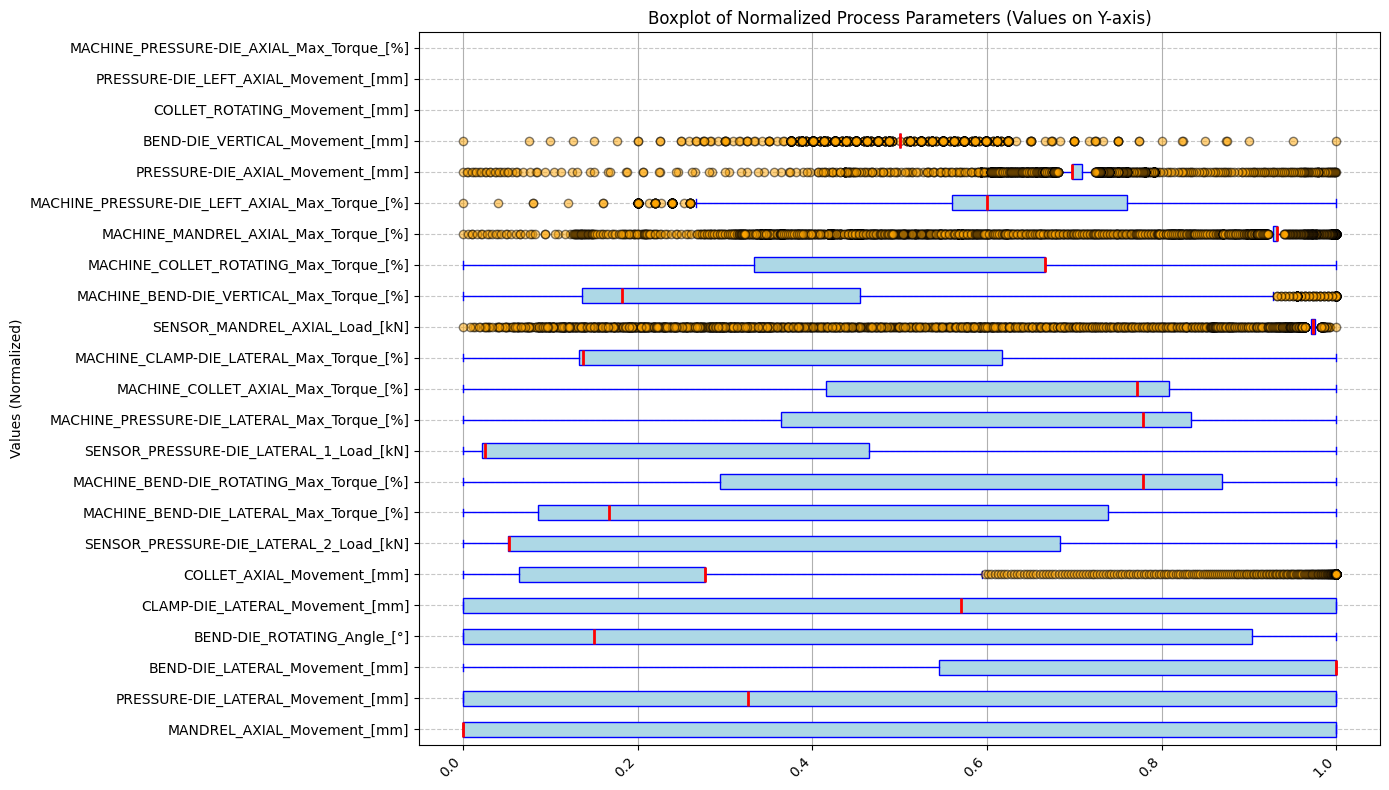

In [185]:
import matplotlib.pyplot as plt

# Sort columns by variance
variances = df_process_parameters_norm.var().sort_values(ascending=False)
sorted_cols = variances.index

plt.figure(figsize=(14, 8))
df_process_parameters_norm[sorted_cols].boxplot(
    vert=False,              # values on Y-axis
    patch_artist=True,      # enable colors
    boxprops=dict(facecolor="lightblue", color="blue"),
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="blue"),
    capprops=dict(color="blue"),
    flierprops=dict(marker='o', markerfacecolor='orange', alpha=0.5)
)

plt.title("Boxplot of Normalized Process Parameters (Values on Y-axis)")
plt.ylabel("Values (Normalized)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Construct geometry data frame

In [186]:
df_geometry_data = experiment_as_dictinary['geometry_data_key_characteristics_arc'].drop(columns= ['Tube_Section'])
df_geometry_data.index = df_geometry_data['Angle[degree]ORDistance[mm]']
df_geometry_data.drop(columns=['Angle[degree]ORDistance[mm]'], inplace=True)
df_geometry_data = df_geometry_data.apply(pd.to_numeric, errors='coerce')
df_geometry_data.tail()

,Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
Angle[degree]ORDistance[mm],,,,
41.00,22.150528,21.334929,0.037020,-0.696629
42.00,22.144354,21.339386,0.036537,-0.692172
43.00,22.135644,21.339377,0.036142,-0.692181
44.00,22.128793,21.341037,0.035756,-0.690521
44.71,22.127360,21.345171,0.035503,-0.686387


# Plot and normalize

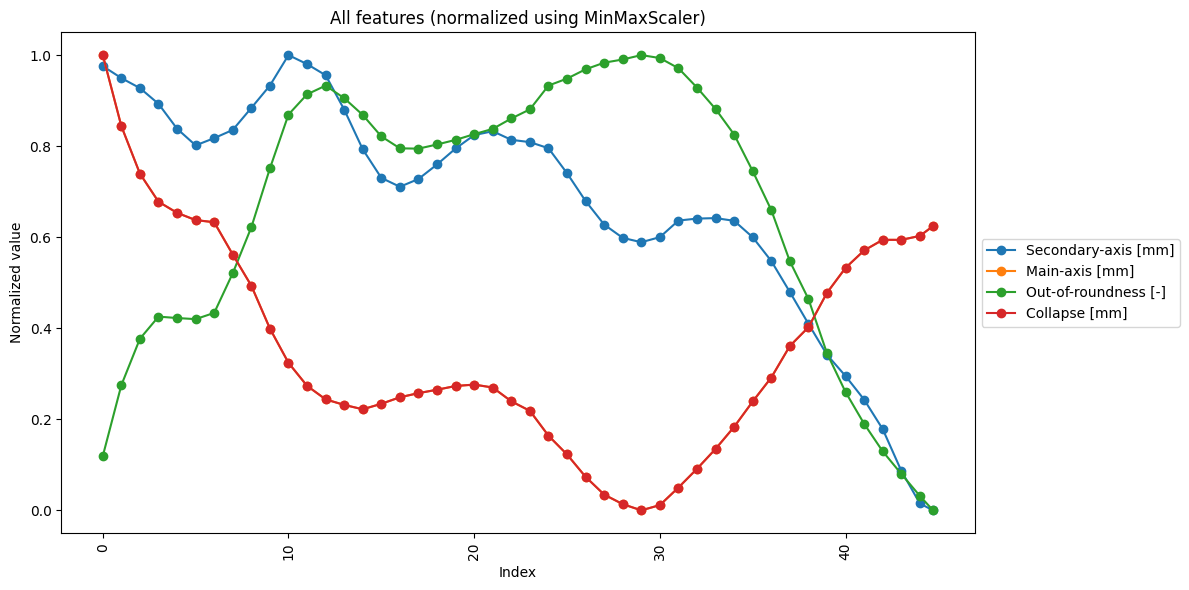

In [187]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the data
df_geometry_data_norm = pd.DataFrame(
    scaler.fit_transform(df_geometry_data),
    columns=df_geometry_data.columns,
    index=df_geometry_data.index
)

plt.figure(figsize=(12, 6))

# Plot all columns in one figure
for col in df_geometry_data_norm.columns:
    plt.plot(df_geometry_data_norm.index, df_geometry_data_norm[col], marker="o", label=col)

plt.title("All features (normalized using MinMaxScaler)")
plt.xlabel("Index")
plt.ylabel("Normalized value")
plt.xticks(rotation=90)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))  # legend outside
plt.tight_layout()
plt.show()

In [188]:
df_geometry_data_norm

,Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
Angle[degree]ORDistance[mm],,,,
0.00,0.975908,1.000000,0.119186,1.000000
1.00,0.949476,0.843971,0.275013,0.843971
2.00,0.927522,0.739580,0.376955,0.739580
3.00,0.892979,0.677872,0.425529,0.677872
4.00,0.838261,0.653530,0.422424,0.653530
5.00,0.801681,0.637571,0.420005,0.637571
6.00,0.817609,0.632880,0.433752,0.632880
7.00,0.835643,0.561838,0.520996,0.561838
8.00,0.883994,0.493340,0.621893,0.493340


# See the statistical property(Variance)

In [189]:
df_geometry_data.var().sort_values()

Out-of-roundness [-]    0.000006
Secondary-axis [mm]     0.000610
Collapse [mm]           0.002125
Main-axis [mm]          0.002125
dtype: float64

In [190]:
df_geometry_data_norm.var().sort_values()

Collapse [mm]           0.057791
Main-axis [mm]          0.057791
Secondary-axis [mm]     0.067192
Out-of-roundness [-]    0.094147
dtype: float64

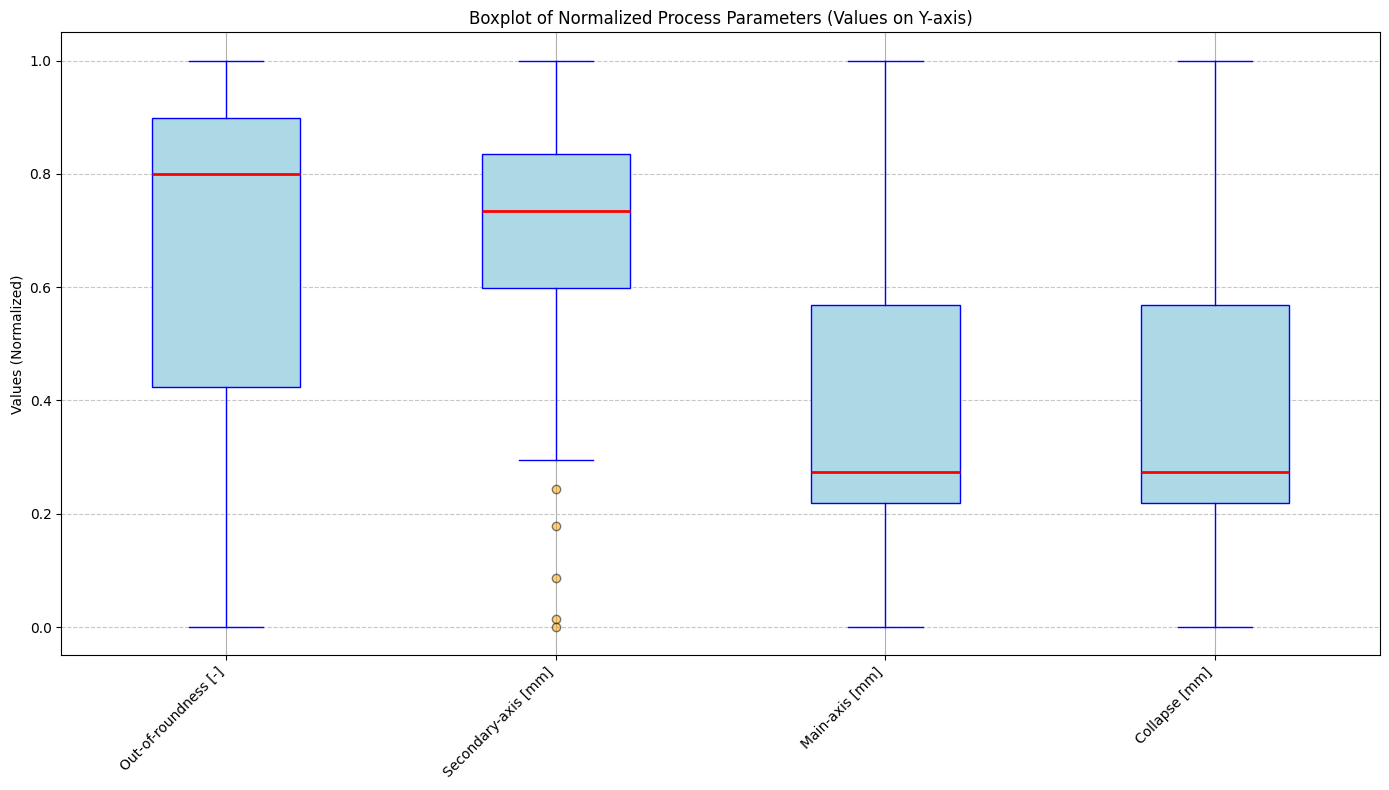

In [191]:
import matplotlib.pyplot as plt

# Sort columns by variance
variances = df_geometry_data_norm.var().sort_values(ascending=False)
sorted_cols = variances.index

plt.figure(figsize=(14, 8))
df_geometry_data_norm[sorted_cols].boxplot(
    vert=True,              # values on Y-axis
    patch_artist=True,      # enable colors
    boxprops=dict(facecolor="lightblue", color="blue"),
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="blue"),
    capprops=dict(color="blue"),
    flierprops=dict(marker='o', markerfacecolor='orange', alpha=0.5)
)

plt.title("Boxplot of Normalized Process Parameters (Values on Y-axis)")
plt.ylabel("Values (Normalized)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Align windows in two data set

In [192]:
def plot_highlight_parts_list(dfs, parts, part_idx):
    part_idx = part_idx-1
    n = len(dfs)
    fig, axes = plt.subplots(n, 1, figsize=(12, 5 * n), sharex=False)

    if n == 1:
        axes = [axes]

    colors = plt.cm.tab10.colors

    for ax, df_num in zip(axes, dfs):
        splits = np.array_split(df_num.index, parts)

        if part_idx < 0 or part_idx >= parts:
            raise ValueError(f"part_idx must be between 1 and {parts}")

        selected_idx = splits[part_idx]
        selected = df_num.loc[selected_idx]

        # Plot all gray lines at once
        ax.plot(df_num.index, df_num.values, color="gray", linewidth=1, zorder=1)

        # Rectangle boundaries
        x_min, x_max = selected.index.min(), selected.index.max()
        y_min, y_max = df_num.min().min(), df_num.max().max()

        rect = Rectangle((x_min, y_min),
                         x_max - x_min,
                         y_max - y_min,
                         linewidth=0,
                         facecolor="red",
                         alpha=0.2,
                         zorder=0)
        ax.add_patch(rect)

        # Plot selected colored lines
        lines = ax.plot(selected.index, selected.values, linewidth=2, zorder=2)
        # Set colors and create legend entries
        for i, line in enumerate(lines):
            line.set_color(colors[i % 10])
        
        ax.set_ylabel("Values")
        ax.set_title(f"Highlighted Part {part_idx+1} of {parts}")
        ax.grid(True)
        
        # Create legend with column names
        ax.legend(lines, df_num.columns.tolist(), bbox_to_anchor=(1.05, 1), loc='upper left')

    axes[-1].set_xlabel("Index")
    plt.tight_layout()
    plt.show()

    # return [df.loc[np.array_split(df.index, parts)[part_idx]] for df in dfs]  # return selected parts


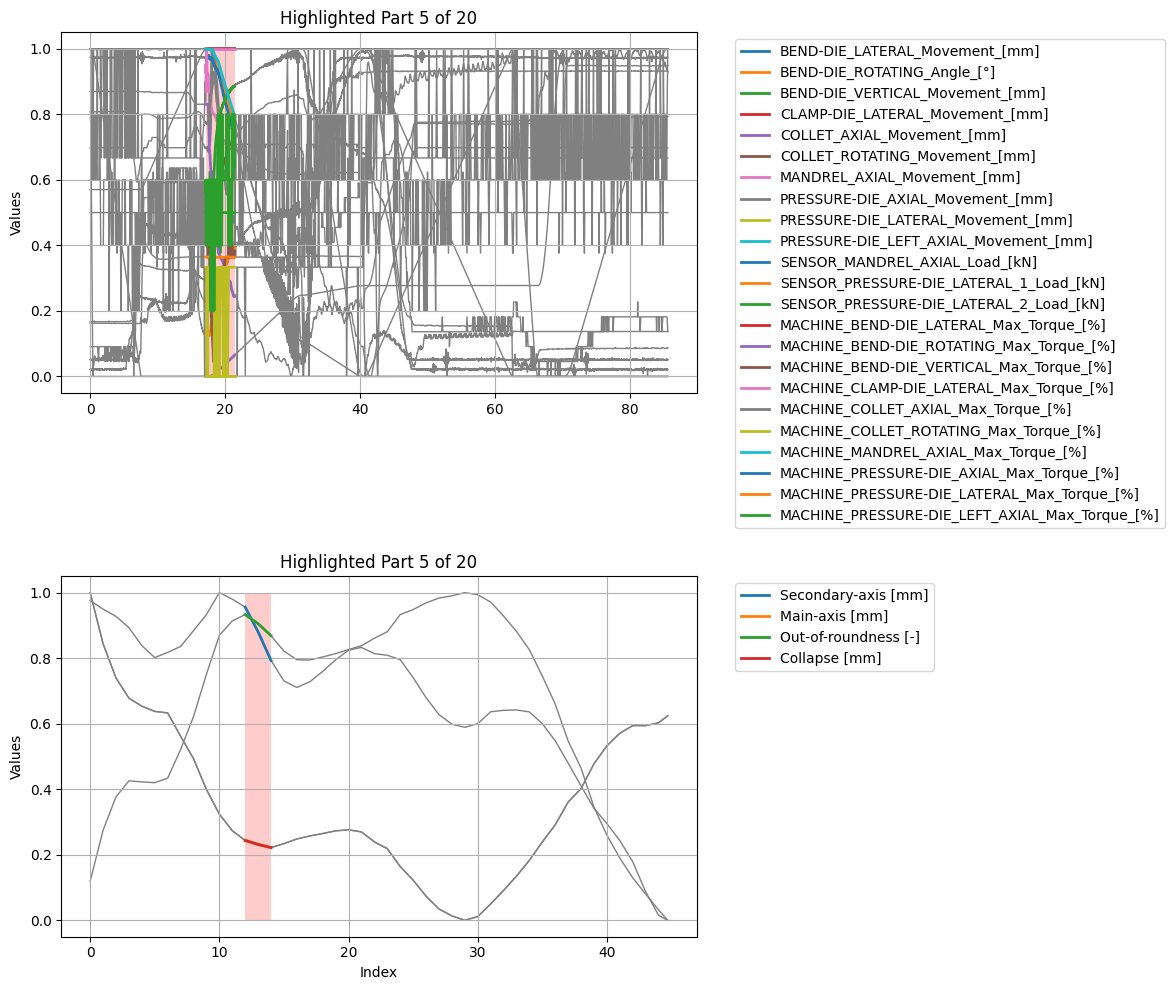

In [193]:
plot_highlight_parts_list(dfs=[df_process_parameters_norm, df_geometry_data_norm], parts = 20, part_idx=5)

In [225]:
y = df_geometry_data_norm['Collapse [mm]'] #.loc[angle]  #'Collapse [mm]'

# Make sure features and target are aligned in time or index
X = df_process_parameters_norm.copy()  # shape (n_samples, n_features)

print(f"y shape: {y.shape}\nX shape: {X.shape}")

y shape: (46,)
X shape: (8562, 23)


In [226]:
import numpy as np
import pandas as pd
from scipy.interpolate import make_interp_spline

# Build index for y (original positions)
orig_idx = np.linspace(0, len(X) - 1, num=len(y))

# Build new index for X (expanded positions)
new_idx = np.arange(len(X))

# Fit a B-spline interpolator
spline = make_interp_spline(orig_idx, y.values, k=5)  # k=3 → cubic B-spline

# Interpolate to match X length
y_expanded = spline(new_idx)

# Trim X to match (should align now)
X_trimmed = X.iloc[:len(y_expanded)]

print(X_trimmed.shape, y_expanded.shape)


(8562, 23) (8562,)


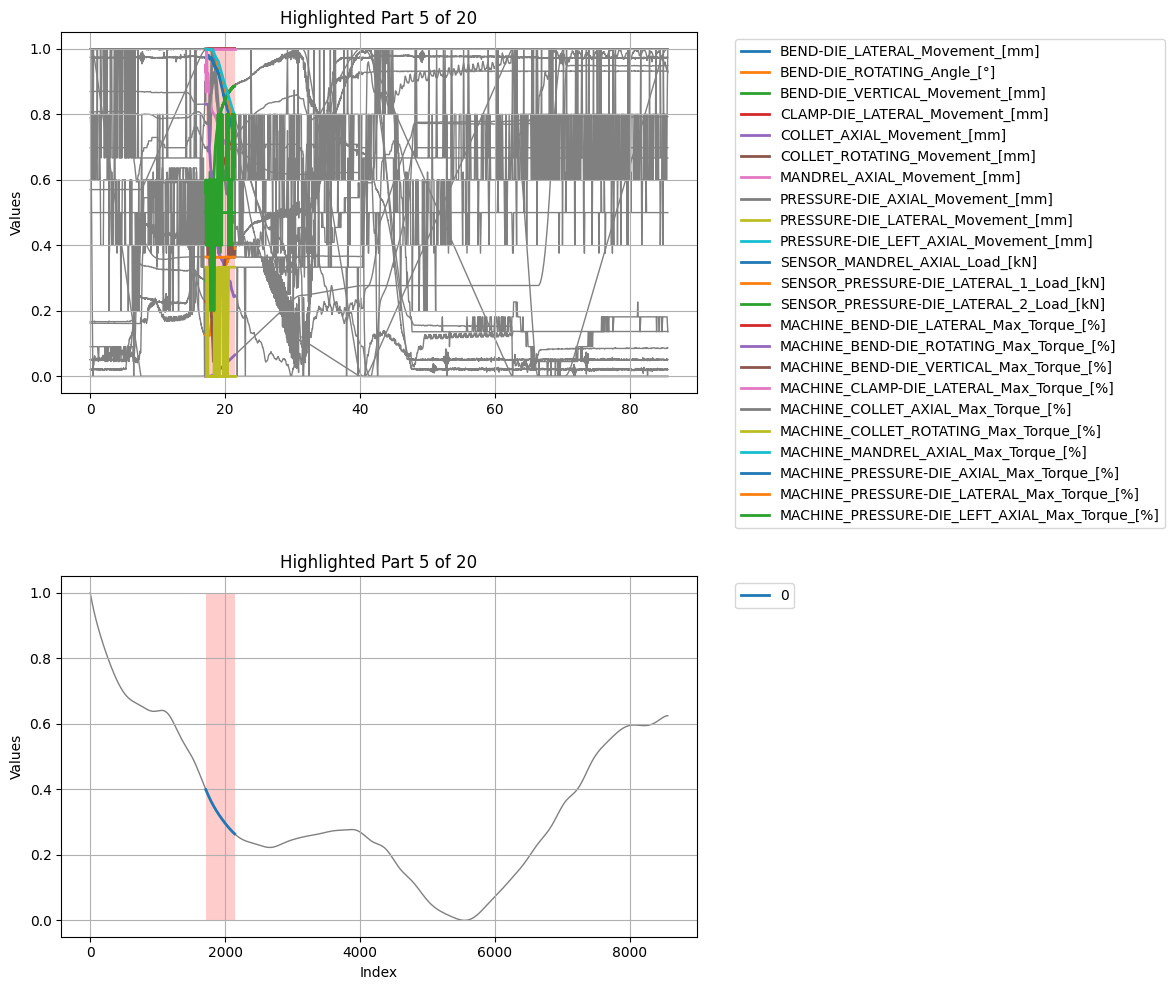

In [227]:
plot_highlight_parts_list(dfs=[pd.DataFrame(X_trimmed), pd.DataFrame(y_expanded)], parts = 20, part_idx=5)

Test MSE: 0.0000

XGBoost built-in feature importance (gain):


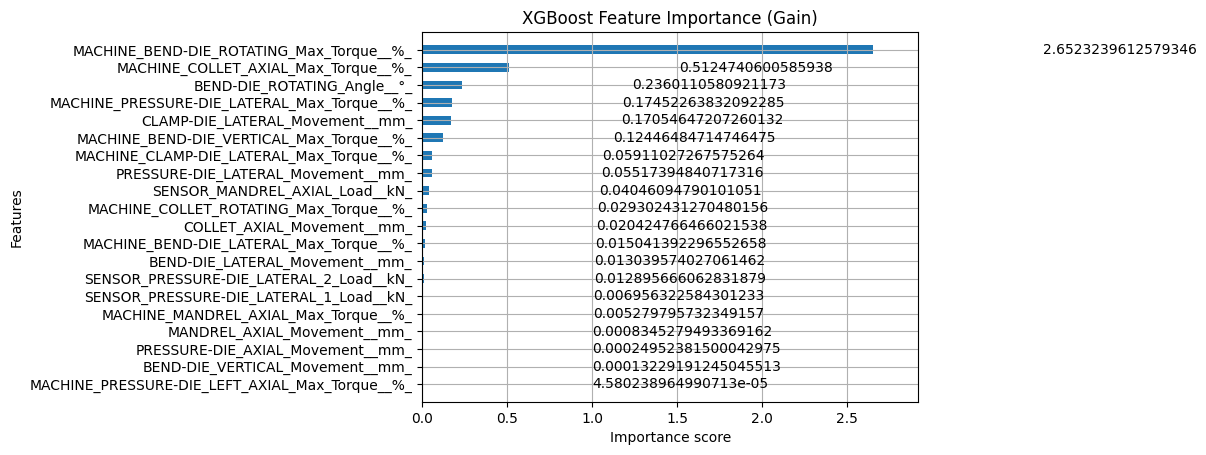


Permutation Importance:


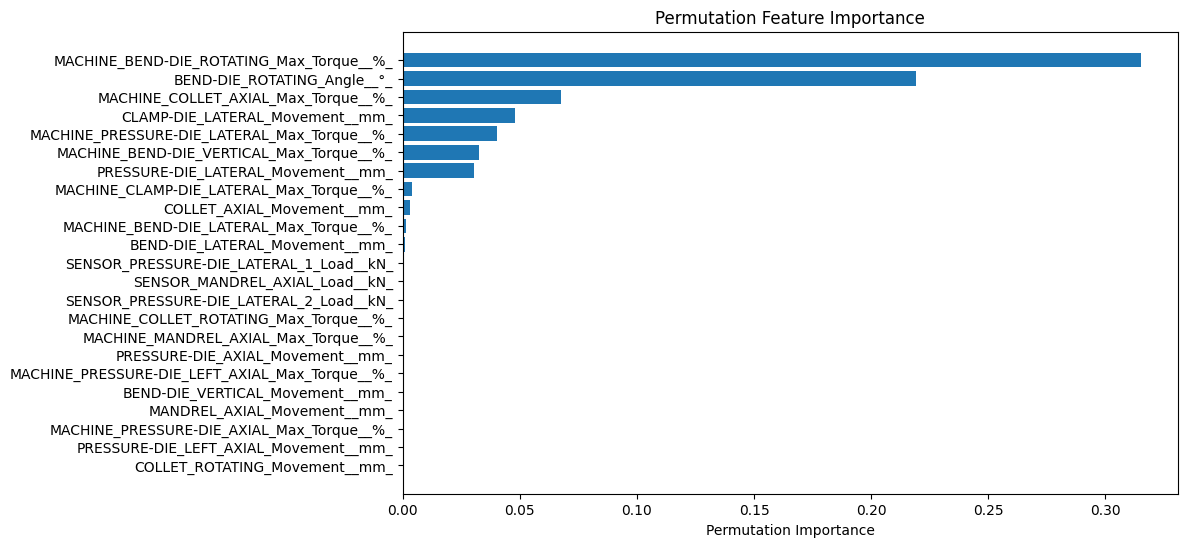

 97%|=================== | 1667/1713 [00:26<00:00]       


Feature effect (mean absolute SHAP value) ranking:
1. MACHINE_BEND-DIE_ROTATING_Max_Torque__%_: 0.0871
2. BEND-DIE_ROTATING_Angle__°_: 0.0560
3. MACHINE_COLLET_AXIAL_Max_Torque__%_: 0.0368
4. MACHINE_PRESSURE-DIE_LATERAL_Max_Torque__%_: 0.0191
5. CLAMP-DIE_LATERAL_Movement__mm_: 0.0153
6. MACHINE_BEND-DIE_VERTICAL_Max_Torque__%_: 0.0126
7. PRESSURE-DIE_LATERAL_Movement__mm_: 0.0105
8. COLLET_AXIAL_Movement__mm_: 0.0066
9. MACHINE_CLAMP-DIE_LATERAL_Max_Torque__%_: 0.0059
10. MACHINE_BEND-DIE_LATERAL_Max_Torque__%_: 0.0033
11. BEND-DIE_LATERAL_Movement__mm_: 0.0021
12. SENSOR_MANDREL_AXIAL_Load__kN_: 0.0017
13. SENSOR_PRESSURE-DIE_LATERAL_2_Load__kN_: 0.0015
14. SENSOR_PRESSURE-DIE_LATERAL_1_Load__kN_: 0.0015
15. MACHINE_MANDREL_AXIAL_Max_Torque__%_: 0.0014
16. MACHINE_COLLET_ROTATING_Max_Torque__%_: 0.0003
17. PRESSURE-DIE_AXIAL_Movement__mm_: 0.0002
18. MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque__%_: 0.0001
19. MANDREL_AXIAL_Movement__mm_: 0.0001
20. BEND-DIE_VERTICAL_Movement__mm_: 0

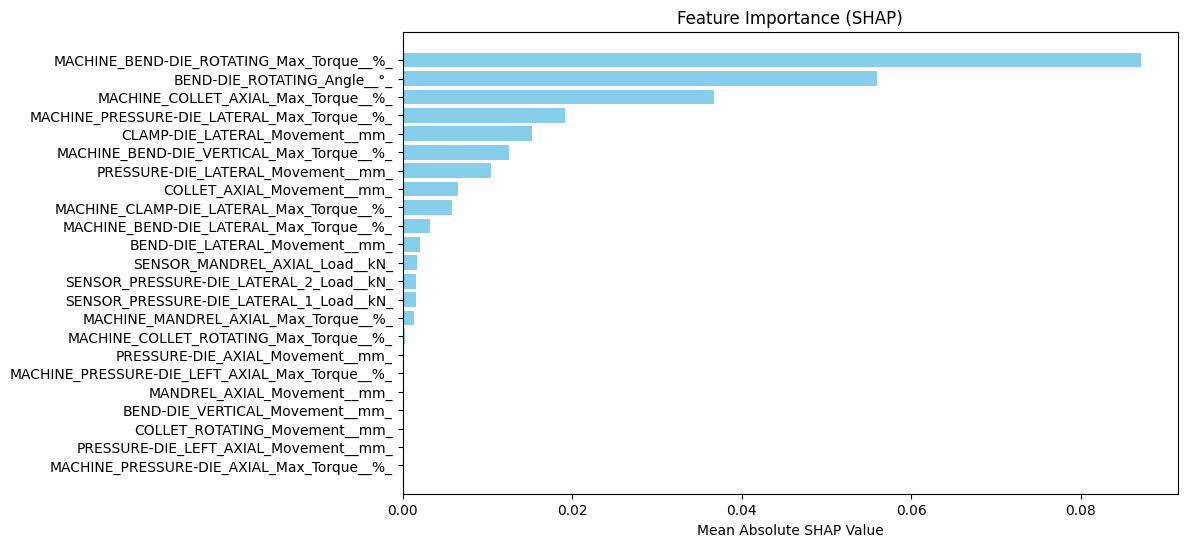

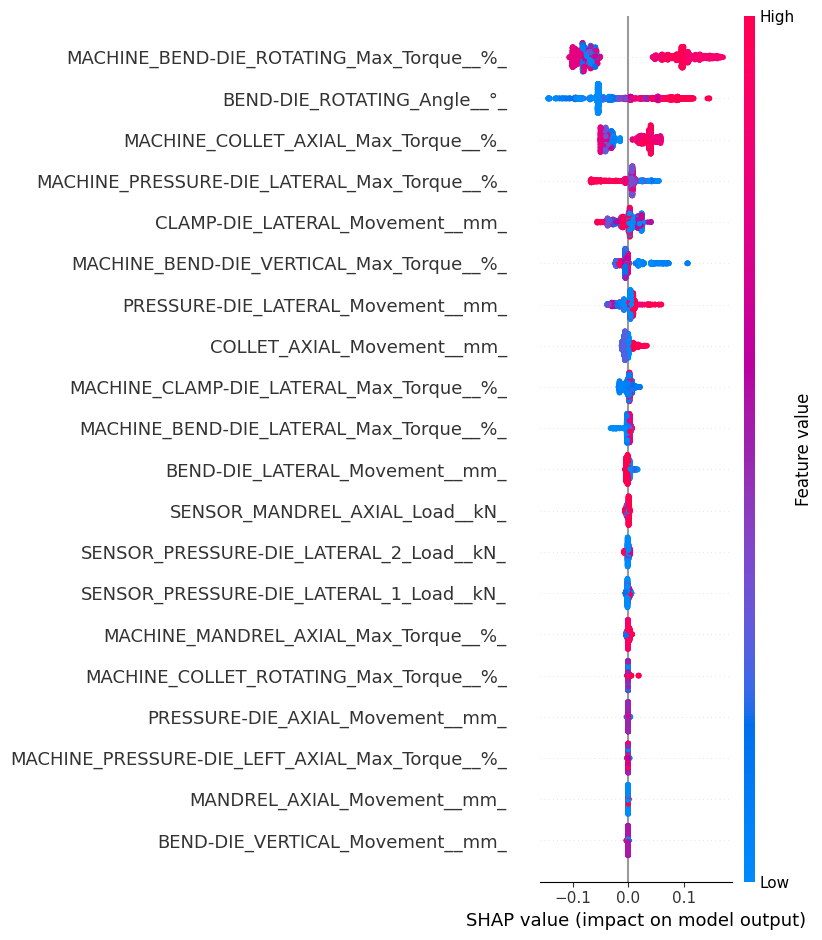

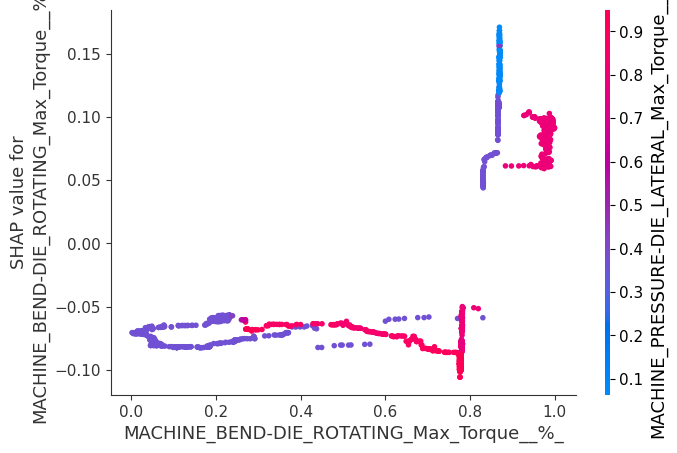

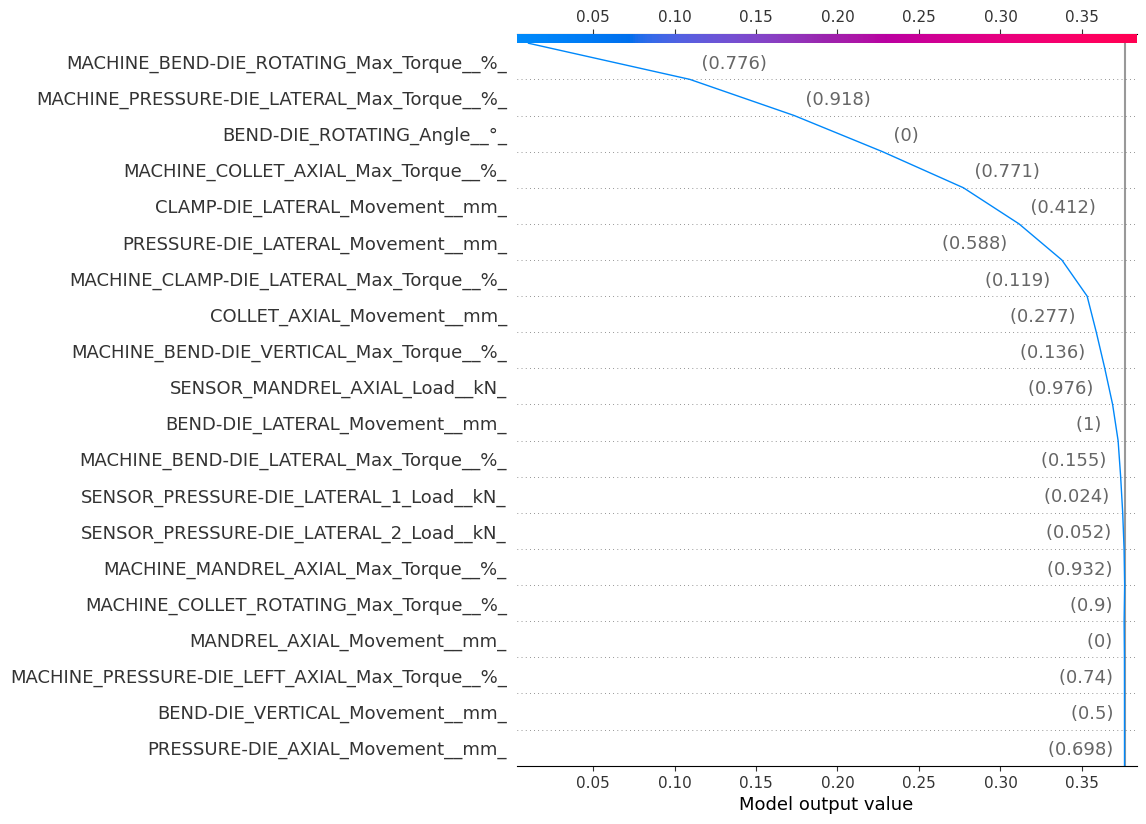

In [229]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance
# --- Prepare data ---
X_safe = X_trimmed.copy()
X_safe.columns = [
    c.replace("[", "_").replace("]", "_").replace("<", "_").replace(":", "_").replace(" ", "_")
    for c in X_safe.columns
]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_safe, y_expanded, test_size=0.2, random_state=42
)

# Train model
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

# Predict & evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.4f}")

# ====================================================
# --- Method 1: XGBoost built-in feature importance ---
# ====================================================
print("\nXGBoost built-in feature importance (gain):")
xgb.plot_importance(model, importance_type="gain", height=0.5, max_num_features=20)
plt.title("XGBoost Feature Importance (Gain)")
plt.show()

# ====================================================
# --- Method 2: Permutation Importance (sklearn) -----
# ====================================================
print("\nPermutation Importance:")
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = perm_importance.importances_mean.argsort()[::-1]

plt.figure(figsize=(10, 6))
plt.barh(X_test.columns[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")
plt.title("Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.show()

# ====================================================
# --- Method 3: SHAP Values (global + local) ---------
# ====================================================
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Mean absolute SHAP values
shap_abs_mean = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_ABS_SHAP': np.abs(shap_values.values).mean(axis=0)
}).sort_values(by='Mean_ABS_SHAP', ascending=False)

print("\nFeature effect (mean absolute SHAP value) ranking:")
for i, row in enumerate(shap_abs_mean.itertuples(), 1):
    print(f"{i}. {row.Feature}: {row.Mean_ABS_SHAP:.4f}")

# Bar plot
plt.figure(figsize=(10, 6))
plt.barh(shap_abs_mean['Feature'], shap_abs_mean['Mean_ABS_SHAP'], color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel('Mean Absolute SHAP Value')
plt.title('Feature Importance (SHAP)')
plt.show()

# SHAP summary plot (global explanation)
shap.summary_plot(shap_values, X_test)

# SHAP dependence plot (example for top feature)
top_feature = shap_abs_mean.iloc[0]['Feature']
shap.dependence_plot(top_feature, shap_values.values, X_test)

# SHAP decision plot (example for one instance)
shap.decision_plot(explainer.expected_value, shap_values.values[0, :], X_test.iloc[0, :])
